model comparison - cancer dataset
----------------------------------------
decision tree -> cv accuracy: 0.917
random forest -> cv accuracy: 0.956
xgboost -> cv accuracy: 0.97


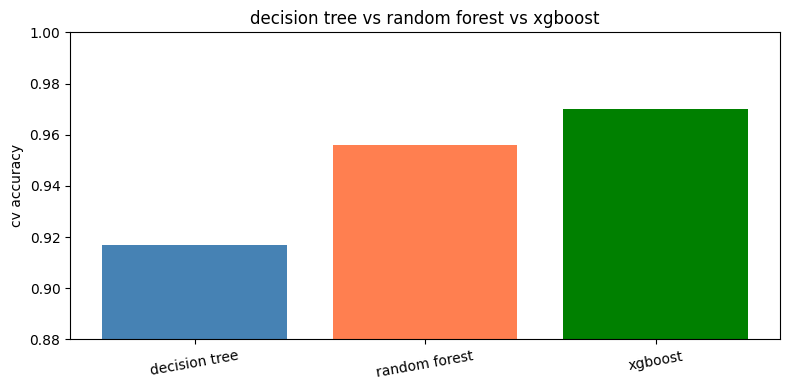

In [2]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

models = {
    "decision tree":  DecisionTreeClassifier(random_state=42),
    "random forest":  RandomForestClassifier(n_estimators=100, random_state=42),
    "xgboost":        xgb.XGBClassifier(n_estimators=100,
                                         random_state=42,
                                         eval_metric="logloss",
                                         verbosity=0)
}

print("model comparison - cancer dataset")
print("-" * 40)

cv_scores = {}
for name, model in models.items():
    cv = cross_val_score(model, x_scaled, y, cv=5)
    cv_scores[name] = round(np.mean(cv), 3)
    print(name, "-> cv accuracy:", cv_scores[name])

plt.figure(figsize=(8, 4))
plt.bar(cv_scores.keys(), cv_scores.values(),
        color=["steelblue", "coral", "green"])
plt.title("decision tree vs random forest vs xgboost")
plt.ylabel("cv accuracy")
plt.ylim(0.88, 1.0)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()